In [1]:
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict, deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 6740
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [4]:
DATA_FILE = Path("results.xlsx")
SHEET_NAME = "results"

df = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (49504, 15)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_coach_nationality,away_coach_nationality,home_elo_rank,away_elo_rank,home_fifa_rank,away_fifa_rank
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Not found,Not found,1,1,Not found,Not found
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Not found,Not found,1,2,Not found,Not found
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Not found,Not found,2,1,Not found,Not found
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Not found,Not found,1,2,Not found,Not found
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Not found,Not found,1,2,Not found,Not found



Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_coach_nationality', 'away_coach_nationality', 'home_elo_rank', 'away_elo_rank', 'home_fifa_rank', 'away_fifa_rank']


In [6]:
df = df.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")

rank_columns = [
    "home_elo_rank",
    "away_elo_rank",
    "home_fifa_rank",
    "away_fifa_rank"
]

for col in rank_columns:
    df[col] = (
        df[col]
        .replace(["Not found", "not found", "", "NA", "N/A"], np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

def convert_neutral(value):
    if pd.isna(value):
        return 0
    if isinstance(value, bool):
        return int(value)
    text = str(value).strip().lower()
    return int(text in {"true", "1", "yes", "y"})

df["neutral"] = df["neutral"].apply(convert_neutral)

text_columns = [
    "home_team",
    "away_team",
    "tournament",
    "home_coach_nationality",
    "away_coach_nationality"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

df = (
    df.dropna(subset=[
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ])
    .sort_values("date")
    .reset_index(drop=True)
)

print("Cleaned shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())


Cleaned shape: (49499, 15)
Date range: 1872-11-30 00:00:00 to 2026-07-06 00:00:00


In [7]:
TEAM_NAME_MAP = {
    "USA": "United States",
    "United States of America": "United States",
    "Korea Republic": "South Korea",
    "Korea DPR": "North Korea",
    "Czech Republic": "Czechia",
    "Türkiye": "Turkey",
    "Côte d'Ivoire": "Ivory Coast",
    "Côte d’Ivoire": "Ivory Coast",
    "IR Iran": "Iran",
    "China PR": "China",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Congo DR": "DR Congo"
}

def clean_team_name(value):
    if pd.isna(value):
        return value
    value = str(value).strip()
    return TEAM_NAME_MAP.get(value, value)

df["home_team"] = df["home_team"].apply(clean_team_name)
df["away_team"] = df["away_team"].apply(clean_team_name)


In [8]:
WORLD_CUP_2026_START = pd.Timestamp("2026-06-11")

df_model = df[df["date"] < WORLD_CUP_2026_START].copy()

assert df_model["date"].max() < WORLD_CUP_2026_START

print("Last match used:", df_model["date"].max())
print("Matches retained:", len(df_model))


Last match used: 2026-06-10 00:00:00
Matches retained: 49405


In [9]:
df_model["result"] = np.select(
    [
        df_model["home_score"] > df_model["away_score"],
        df_model["home_score"] < df_model["away_score"]
    ],
    ["H", "A"],
    default="D"
)

print(df_model["result"].value_counts())
print("\nProportions:")
print(df_model["result"].value_counts(normalize=True).round(3))


result
H    24212
A    13960
D    11233
Name: count, dtype: int64

Proportions:
result
H    0.490
A    0.283
D    0.227
Name: proportion, dtype: float64


In [10]:
FORM_WINDOW = 10

team_history = defaultdict(lambda: deque(maxlen=FORM_WINDOW))
feature_rows = []

def summarize_history(history):
    history = list(history)

    if len(history) == 0:
        return {
            "prior_matches": 0,
            "win_rate": 0.33,
            "draw_rate": 0.34,
            "goals_for": 1.20,
            "goals_against": 1.20,
            "goal_difference": 0.0
        }

    wins = np.mean([game["result"] == "W" for game in history])
    draws = np.mean([game["result"] == "D" for game in history])
    goals_for = np.mean([game["gf"] for game in history])
    goals_against = np.mean([game["ga"] for game in history])

    return {
        "prior_matches": len(history),
        "win_rate": wins,
        "draw_rate": draws,
        "goals_for": goals_for,
        "goals_against": goals_against,
        "goal_difference": goals_for - goals_against
    }

for _, match in df_model.iterrows():
    home = match["home_team"]
    away = match["away_team"]

    home_form = summarize_history(team_history[home])
    away_form = summarize_history(team_history[away])

    home_coach = str(match["home_coach_nationality"]).strip()
    away_coach = str(match["away_coach_nationality"]).strip()

    home_same_coach = int(
        home_coach.lower() not in {"not found", "<na>", "nan", ""}
        and clean_team_name(home_coach) == clean_team_name(home)
    )
    away_same_coach = int(
        away_coach.lower() not in {"not found", "<na>", "nan", ""}
        and clean_team_name(away_coach) == clean_team_name(away)
    )

    feature_rows.append({
        "date": match["date"],
        "home_team": home,
        "away_team": away,
        "home_score": match["home_score"],
        "away_score": match["away_score"],
        "tournament": match["tournament"],
        "neutral": match["neutral"],
        "result": match["result"],

        # A positive value means the home team has the better rank
        "elo_rank_advantage": (
            match["away_elo_rank"] - match["home_elo_rank"]
            if pd.notna(match["home_elo_rank"]) and pd.notna(match["away_elo_rank"])
            else np.nan
        ),
        "fifa_rank_advantage": (
            match["away_fifa_rank"] - match["home_fifa_rank"]
            if pd.notna(match["home_fifa_rank"]) and pd.notna(match["away_fifa_rank"])
            else np.nan
        ),

        "win_rate_diff": home_form["win_rate"] - away_form["win_rate"],
        "draw_rate_diff": home_form["draw_rate"] - away_form["draw_rate"],
        "goals_for_diff": home_form["goals_for"] - away_form["goals_for"],
        "goals_against_diff": home_form["goals_against"] - away_form["goals_against"],
        "goal_difference_diff": (
            home_form["goal_difference"] - away_form["goal_difference"]
        ),
        "experience_diff": (
            home_form["prior_matches"] - away_form["prior_matches"]
        ),
        "same_nation_coach_diff": home_same_coach - away_same_coach
    })

    if match["home_score"] > match["away_score"]:
        home_result, away_result = "W", "L"
    elif match["home_score"] < match["away_score"]:
        home_result, away_result = "L", "W"
    else:
        home_result, away_result = "D", "D"

    team_history[home].append({
        "gf": match["home_score"],
        "ga": match["away_score"],
        "result": home_result
    })
    team_history[away].append({
        "gf": match["away_score"],
        "ga": match["home_score"],
        "result": away_result
    })

model_data = pd.DataFrame(feature_rows)

print("Engineered dataset shape:", model_data.shape)
display(model_data.head())


Engineered dataset shape: (49405, 17)


,date,home_team,away_team,home_score,away_score,tournament,neutral,result,elo_rank_advantage,fifa_rank_advantage,win_rate_diff,draw_rate_diff,goals_for_diff,goals_against_diff,goal_difference_diff,experience_diff,same_nation_coach_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,0,D,0,NaN,0.0,0.0,0.000000,0.000000,0.000000,0,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,0,H,1,NaN,0.0,0.0,0.000000,0.000000,0.000000,0,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,0,H,-1,NaN,-0.5,0.0,-1.000000,1.000000,-2.000000,0,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,0,D,1,NaN,0.0,0.0,0.333333,-0.333333,0.666667,0,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,0,H,1,NaN,0.0,0.0,-0.250000,0.250000,-0.500000,0,0


In [11]:
FEATURES = [
    "elo_rank_advantage",
    "fifa_rank_advantage",
    "win_rate_diff",
    "draw_rate_diff",
    "goals_for_diff",
    "goals_against_diff",
    "goal_difference_diff",
    "experience_diff",
    "same_nation_coach_diff",
    "neutral"
]

TARGET = "result"

print(model_data[FEATURES].isna().sum())


elo_rank_advantage            0
fifa_rank_advantage       22540
win_rate_diff                 0
draw_rate_diff                0
goals_for_diff                0
goals_against_diff            0
goal_difference_diff          0
experience_diff               0
same_nation_coach_diff        0
neutral                       0
dtype: int64


In [12]:
MODERN_START = pd.Timestamp("1993-01-01")

modern_data = model_data[model_data["date"] >= MODERN_START].copy()

print("Modern modeling matches:", len(modern_data))
print("Modern date range:", modern_data["date"].min(), "to", modern_data["date"].max())

Modern modeling matches: 30697
Modern date range: 1993-01-01 00:00:00 to 2026-06-10 00:00:00


In [13]:
def build_knn(k):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=k,
            weights="distance",
            metric="euclidean"
        ))
    ])


In [14]:
WORLD_CUP_WINDOWS = [
    (
        "2014",
        pd.Timestamp("2014-06-12"),
        pd.Timestamp("2014-07-13")
    ),
    (
        "2018",
        pd.Timestamp("2018-06-14"),
        pd.Timestamp("2018-07-15")
    ),
    (
        "2022",
        pd.Timestamp("2022-11-20"),
        pd.Timestamp("2022-12-18")
    )
]

K_VALUES = [5, 9, 13, 17, 21, 25, 31, 41, 51]

validation_records = []

for k in K_VALUES:
    fold_losses = []
    fold_accuracies = []

    for fold_name, start_date, end_date in WORLD_CUP_WINDOWS:
        train = modern_data[modern_data["date"] < start_date].copy()
        valid = modern_data[
            (modern_data["date"] >= start_date)
            & (modern_data["date"] <= end_date)
            & modern_data["tournament"].str.contains(
                "World Cup", case=False, na=False
            )
        ].copy()

        if len(train) == 0 or len(valid) == 0:
            continue

        model = build_knn(k)
        model.fit(train[FEATURES], train[TARGET])

        pred = model.predict(valid[FEATURES])
        proba = model.predict_proba(valid[FEATURES])

        fold_accuracies.append(
            accuracy_score(valid[TARGET], pred)
        )
        fold_losses.append(
            log_loss(
                valid[TARGET],
                proba,
                labels=model.classes_
            )
        )

        validation_records.append({
            "k": k,
            "fold": fold_name,
            "matches": len(valid),
            "accuracy": fold_accuracies[-1],
            "log_loss": fold_losses[-1]
        })

validation_detail = pd.DataFrame(validation_records)

validation_summary = (
    validation_detail
    .groupby("k", as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_log_loss=("log_loss", "mean"),
        folds=("fold", "nunique")
    )
    .sort_values(["mean_log_loss", "mean_accuracy"], ascending=[True, False])
)

display(validation_summary)

BEST_K = int(validation_summary.iloc[0]["k"])
print("Selected K:", BEST_K)


,k,mean_accuracy,mean_log_loss,folds
8,51,0.531250,1.012908,3
7,41,0.505208,1.021169,3
6,31,0.484375,1.051693,3
5,25,0.500000,1.057054,3
4,21,0.463542,1.087007,3
3,17,0.468750,1.101459,3
2,13,0.479167,1.447051,3
1,9,0.442708,1.810053,3
0,5,0.437500,6.401118,3


Selected K: 51


##  Plot validation performance


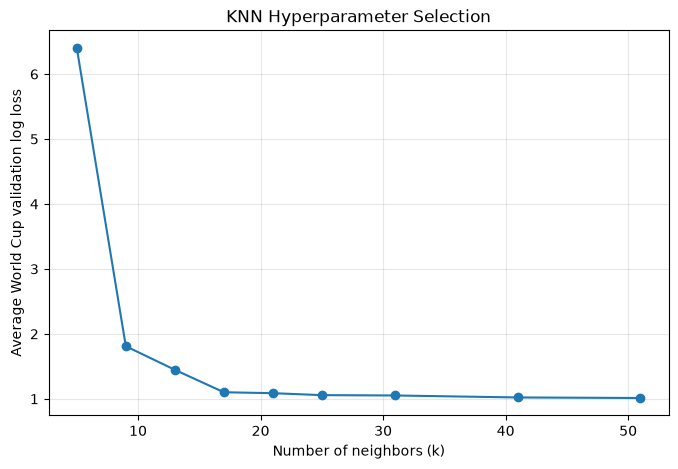

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    validation_summary["k"],
    validation_summary["mean_log_loss"],
    marker="o"
)
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Average World Cup validation log loss")
plt.title("KNN Hyperparameter Selection")
plt.grid(alpha=0.3)
plt.show()


In [16]:
train_2022 = modern_data[
    modern_data["date"] < pd.Timestamp("2022-11-20")
].copy()

test_2022 = modern_data[
    (modern_data["date"] >= pd.Timestamp("2022-11-20"))
    & (modern_data["date"] <= pd.Timestamp("2022-12-18"))
    & modern_data["tournament"].str.contains(
        "World Cup", case=False, na=False
    )
].copy()

historical_model = build_knn(BEST_K)
historical_model.fit(train_2022[FEATURES], train_2022[TARGET])

test_pred = historical_model.predict(test_2022[FEATURES])
test_proba = historical_model.predict_proba(test_2022[FEATURES])

print("2022 matches:", len(test_2022))
print("Accuracy:", round(accuracy_score(test_2022[TARGET], test_pred), 4))
print(
    "Balanced accuracy:",
    round(balanced_accuracy_score(test_2022[TARGET], test_pred), 4)
)
print(
    "Log loss:",
    round(
        log_loss(
            test_2022[TARGET],
            test_proba,
            labels=historical_model.classes_
        ),
        4
    )
)

print("\nClassification report:")
print(classification_report(test_2022[TARGET], test_pred, zero_division=0))


2022 matches: 64
Accuracy: 0.5156
Balanced accuracy: 0.4468
Log loss: 1.0487

Classification report:
              precision    recall  f1-score   support

           A       0.48      0.52      0.50        21
           D       0.20      0.07      0.10        15
           H       0.58      0.75      0.66        28

    accuracy                           0.52        64
   macro avg       0.42      0.45      0.42        64
weighted avg       0.46      0.52      0.47        64



## Confusion matrix


,Predicted home win,Predicted draw,Predicted away win
Actual home win,21,1,6
Actual draw,8,1,6
Actual away win,7,3,11


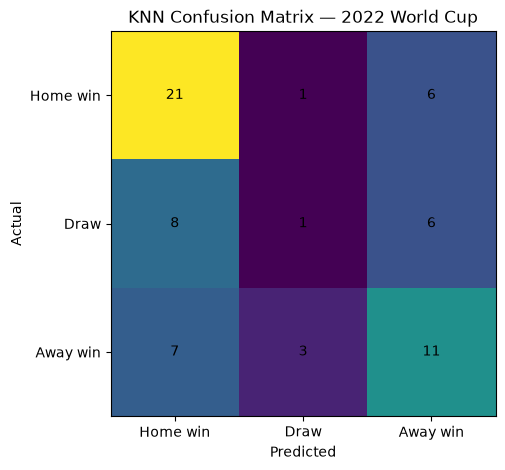

In [17]:
label_order = ["H", "D", "A"]

cm = confusion_matrix(
    test_2022[TARGET],
    test_pred,
    labels=label_order
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual home win", "Actual draw", "Actual away win"],
    columns=["Predicted home win", "Predicted draw", "Predicted away win"]
)

display(cm_df)

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.xticks(range(3), ["Home win", "Draw", "Away win"])
plt.yticks(range(3), ["Home win", "Draw", "Away win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix — 2022 World Cup")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [18]:
final_model = build_knn(BEST_K)
final_model.fit(modern_data[FEATURES], modern_data[TARGET])

print("Final training matches:", len(modern_data))
print("Final training cutoff:", modern_data["date"].max())
print("Class order:", final_model.classes_)


Final training matches: 30697
Final training cutoff: 2026-06-10 00:00:00
Class order: ['A' 'D' 'H']


In [19]:
TEAMS_2026 = [
    # Replace or verify this list using your group's official pre-tournament list.
    "Algeria", "Argentina", "Australia", "Austria",
    "Belgium", "Bosnia and Herzegovina", "Brazil", "Canada",
    "Cape Verde", "Colombia", "Croatia", "Curaçao",
    "Czechia", "DR Congo", "Ecuador", "Egypt",
    "England", "France", "Germany", "Ghana",
    "Haiti", "Iran", "Iraq", "Ivory Coast",
    "Japan", "Jordan", "Mexico", "Morocco",
    "Netherlands", "New Zealand", "Norway", "Panama",
    "Paraguay", "Portugal", "Qatar", "Saudi Arabia",
    "Scotland", "Senegal", "South Africa", "South Korea",
    "Spain", "Sweden", "Switzerland", "Tunisia",
    "Turkey", "United States", "Uruguay", "Uzbekistan"
]

TEAMS_2026 = [clean_team_name(t) for t in TEAMS_2026]

print("Number of listed teams:", len(TEAMS_2026))


Number of listed teams: 48


In [20]:
def latest_nonmissing_value(team, home_col, away_col):
    home_rows = df_model.loc[
        df_model["home_team"] == team,
        ["date", home_col]
    ].rename(columns={home_col: "value"})

    away_rows = df_model.loc[
        df_model["away_team"] == team,
        ["date", away_col]
    ].rename(columns={away_col: "value"})

    combined = (
        pd.concat([home_rows, away_rows], ignore_index=True)
        .dropna(subset=["value"])
        .sort_values("date")
    )

    if combined.empty:
        return np.nan

    return combined.iloc[-1]["value"]


def latest_coach_same_nation(team):
    home_rows = df_model.loc[
        df_model["home_team"] == team,
        ["date", "home_coach_nationality"]
    ].rename(columns={"home_coach_nationality": "coach"})

    away_rows = df_model.loc[
        df_model["away_team"] == team,
        ["date", "away_coach_nationality"]
    ].rename(columns={"away_coach_nationality": "coach"})

    combined = (
        pd.concat([home_rows, away_rows], ignore_index=True)
        .sort_values("date")
    )

    if combined.empty:
        return 0

    coach = str(combined.iloc[-1]["coach"]).strip()

    if coach.lower() in {"not found", "<na>", "nan", ""}:
        return 0

    return int(clean_team_name(coach) == clean_team_name(team))


team_state_rows = []

for team in TEAMS_2026:
    form = summarize_history(team_history[team])

    team_state_rows.append({
        "team": team,
        "elo_rank": latest_nonmissing_value(
            team, "home_elo_rank", "away_elo_rank"
        ),
        "fifa_rank": latest_nonmissing_value(
            team, "home_fifa_rank", "away_fifa_rank"
        ),
        "win_rate": form["win_rate"],
        "draw_rate": form["draw_rate"],
        "goals_for": form["goals_for"],
        "goals_against": form["goals_against"],
        "goal_difference": form["goal_difference"],
        "prior_matches": form["prior_matches"],
        "same_nation_coach": latest_coach_same_nation(team)
    })

team_state = pd.DataFrame(team_state_rows)

display(team_state.sort_values("elo_rank").head(15))
print("\nMissing values:")
print(team_state.isna().sum())


,team,elo_rank,fifa_rank,win_rate,draw_rate,goals_for,goals_against,goal_difference,prior_matches,same_nation_coach
1,Argentina,1,1.0,0.8,0.1,2.5,0.3,2.2,10,0
40,Spain,2,3.0,0.7,0.3,2.8,0.4,2.4,10,0
6,Brazil,3,5.0,0.6,0.1,2.5,1.1,1.4,10,0
17,France,4,2.0,0.8,0.1,2.5,0.9,1.6,10,0
9,Colombia,5,9.0,0.7,0.1,2.5,1.0,1.5,10,0
33,Portugal,6,8.0,0.7,0.2,2.6,0.9,1.7,10,0
16,England,7,4.0,0.8,0.1,2.4,0.2,2.2,10,0
18,Germany,8,13.0,0.9,0.0,2.8,0.8,2.0,10,0
28,Netherlands,11,7.0,0.6,0.3,2.2,0.8,1.4,10,0
46,Uruguay,11,11.0,0.4,0.4,1.0,0.9,0.1,10,0



Missing values:
team                 0
elo_rank             0
fifa_rank            0
win_rate             0
draw_rate            0
goals_for            0
goals_against        0
goal_difference      0
prior_matches        0
same_nation_coach    0
dtype: int64


In [21]:
def create_matchup_features(team_a, team_b):
    a = team_state.loc[team_state["team"] == team_a].iloc[0]
    b = team_state.loc[team_state["team"] == team_b].iloc[0]

    row = pd.DataFrame([{
        "elo_rank_advantage": b["elo_rank"] - a["elo_rank"],
        "fifa_rank_advantage": b["fifa_rank"] - a["fifa_rank"],
        "win_rate_diff": a["win_rate"] - b["win_rate"],
        "draw_rate_diff": a["draw_rate"] - b["draw_rate"],
        "goals_for_diff": a["goals_for"] - b["goals_for"],
        "goals_against_diff": a["goals_against"] - b["goals_against"],
        "goal_difference_diff": (
            a["goal_difference"] - b["goal_difference"]
        ),
        "experience_diff": a["prior_matches"] - b["prior_matches"],
        "same_nation_coach_diff": (
            a["same_nation_coach"] - b["same_nation_coach"]
        ),
        "neutral": 1
    }])

    return row[FEATURES]


In [22]:
def one_direction_probabilities(team_a, team_b):
    X = create_matchup_features(team_a, team_b)
    probability_vector = final_model.predict_proba(X)[0]
    probability_map = dict(zip(final_model.classes_, probability_vector))

    return {
        "a_win": probability_map.get("H", 0.0),
        "draw": probability_map.get("D", 0.0),
        "b_win": probability_map.get("A", 0.0)
    }


def predict_neutral_match(team_a, team_b):
    forward = one_direction_probabilities(team_a, team_b)
    reverse = one_direction_probabilities(team_b, team_a)

    p_a = (forward["a_win"] + reverse["b_win"]) / 2
    p_draw = (forward["draw"] + reverse["draw"]) / 2
    p_b = (forward["b_win"] + reverse["a_win"]) / 2

    total = p_a + p_draw + p_b

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": p_a / total,
        "draw_probability": p_draw / total,
        "team_b_win_probability": p_b / total
    }


display(pd.DataFrame([
    predict_neutral_match("Argentina", "Spain")
]))


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability
0,Argentina,Spain,0.299518,0.263586,0.436896


In [23]:
pairwise_rows = []

for i, team_a in enumerate(TEAMS_2026):
    for team_b in TEAMS_2026[i + 1:]:
        pairwise_rows.append(
            predict_neutral_match(team_a, team_b)
        )

pairwise_predictions = pd.DataFrame(pairwise_rows)

print("Pairings:", len(pairwise_predictions))
display(pairwise_predictions.head())


Pairings: 1128


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability
0,Algeria,Argentina,0.215827,0.262828,0.521345
1,Algeria,Australia,0.387073,0.328621,0.284306
2,Algeria,Austria,0.320793,0.255995,0.423212
3,Algeria,Belgium,0.235932,0.328600,0.435468
4,Algeria,Bosnia and Herzegovina,0.506230,0.271667,0.222103


In [24]:
score_records = defaultdict(lambda: {
    "expected_points": 0.0,
    "expected_wins": 0.0,
    "expected_draws": 0.0,
    "expected_losses": 0.0,
    "opponents": 0
})

for _, row in pairwise_predictions.iterrows():
    team_a = row["team_a"]
    team_b = row["team_b"]

    p_a = row["team_a_win_probability"]
    p_d = row["draw_probability"]
    p_b = row["team_b_win_probability"]

    score_records[team_a]["expected_points"] += 3 * p_a + p_d
    score_records[team_a]["expected_wins"] += p_a
    score_records[team_a]["expected_draws"] += p_d
    score_records[team_a]["expected_losses"] += p_b
    score_records[team_a]["opponents"] += 1

    score_records[team_b]["expected_points"] += 3 * p_b + p_d
    score_records[team_b]["expected_wins"] += p_b
    score_records[team_b]["expected_draws"] += p_d
    score_records[team_b]["expected_losses"] += p_a
    score_records[team_b]["opponents"] += 1

ranking_rows = []

for team, values in score_records.items():
    n = values["opponents"]

    ranking_rows.append({
        "team": team,
        "expected_points_per_match": values["expected_points"] / n,
        "average_win_probability": values["expected_wins"] / n,
        "average_draw_probability": values["expected_draws"] / n,
        "average_loss_probability": values["expected_losses"] / n
    })

knn_ranking_2026 = (
    pd.DataFrame(ranking_rows)
    .sort_values("expected_points_per_match", ascending=False)
    .reset_index(drop=True)
)

knn_ranking_2026.insert(
    0,
    "KNN_rank",
    np.arange(1, len(knn_ranking_2026) + 1)
)

display(knn_ranking_2026)


,KNN_rank,team,expected_points_per_match,average_win_probability,average_draw_probability,average_loss_probability
0,1,Spain,1.866788,0.542020,0.240727,0.217253
1,2,Argentina,1.836361,0.523318,0.266408,0.210275
2,3,Belgium,1.826238,0.529110,0.238908,0.231982
3,4,England,1.819258,0.516975,0.268332,0.214693
4,5,Germany,1.816069,0.516343,0.267040,0.216617
5,6,Brazil,1.736673,0.487776,0.273344,0.238879
6,7,France,1.731720,0.485423,0.275450,0.239126
7,8,Portugal,1.702160,0.477037,0.271048,0.251915
8,9,Colombia,1.698428,0.474768,0.274125,0.251107
9,10,Austria,1.686592,0.471690,0.271522,0.256788


## Plot the top 15 teams


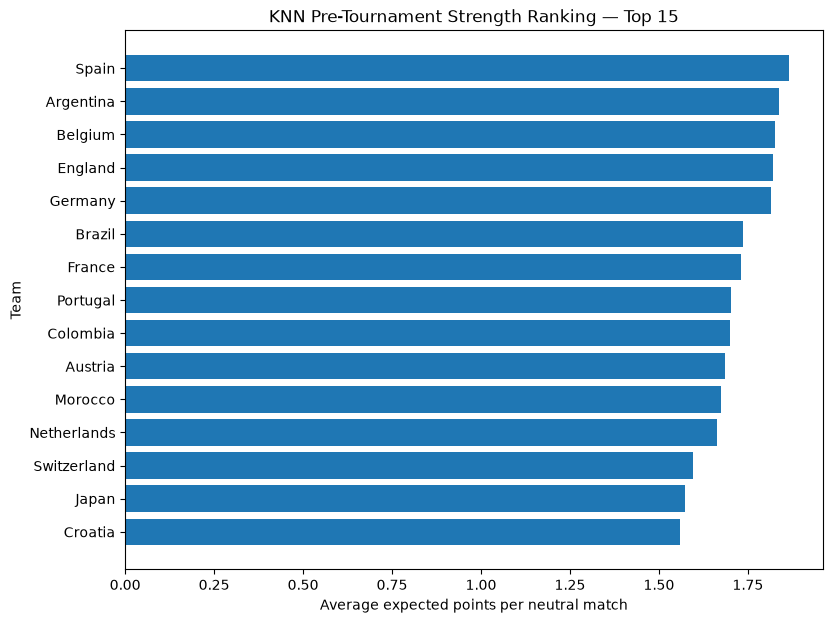

In [25]:
top_15 = (
    knn_ranking_2026
    .head(15)
    .sort_values("expected_points_per_match")
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_15["team"],
    top_15["expected_points_per_match"]
)
plt.xlabel("Average expected points per neutral match")
plt.ylabel("Team")
plt.title("KNN Pre-Tournament Strength Ranking — Top 15")
plt.show()


## Save all outputs

The notebook creates:

- `KNN_2026_team_ranking.csv`
- `KNN_2026_pairwise_probabilities.csv`
- `KNN_validation_results.csv`
- `KNN_2022_test_predictions.csv`


In [26]:
ranking_export = knn_ranking_2026.copy()

for col in [
    "average_win_probability",
    "average_draw_probability",
    "average_loss_probability"
]:
    ranking_export[col] = ranking_export[col].round(6)

ranking_export["expected_points_per_match"] = (
    ranking_export["expected_points_per_match"].round(6)
)

ranking_export.to_csv(
    "KNN_2026_team_ranking.csv",
    index=False
)

pairwise_predictions.to_csv(
    "KNN_2026_pairwise_probabilities.csv",
    index=False
)

validation_detail.to_csv(
    "KNN_validation_results.csv",
    index=False
)

test_output = test_2022[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "result"
    ]
].copy()

test_output["predicted_result"] = test_pred

for index, class_name in enumerate(historical_model.classes_):
    test_output[f"probability_{class_name}"] = test_proba[:, index]

test_output.to_csv(
    "KNN_2022_test_predictions.csv",
    index=False
)

print("Files saved successfully.")


Files saved successfully.


# Interpretation for the project report (I will use them to write my protion)

## What the model does

KNN finds historical matches whose pre-match conditions are most similar to the matchup being predicted. Similarity is based on ranking advantages, recent performance, coach-nationality alignment and venue type.

## Why scaling is required

KNN uses Euclidean distance. Without standardization, a variable with a larger numerical scale could dominate the model.

## Why chronological validation is required

Soccer data are time ordered. A random split could allow future matches to influence predictions of earlier matches. The notebook always trains on earlier data and validates on later World Cups.

## Why match probabilities are predicted instead of final rank directly

Only a few historical World Cups exist, which is too small for a reliable 1–48 ranking model. There are thousands of individual international matches, so predicting win/draw/loss probabilities is more statistically defensible. Those probabilities can feed the Monte Carlo tournament simulation.

## Main limitations

1. Missing FIFA and Elo ranks are imputed.
2. Coach nationality is available for only part of the historical data.
3. KNN can struggle with many correlated features.
4. Draws are often harder to classify than wins.
5. The strength ranking is not the same as tournament-winning probability because bracket paths differ.
6. The participant list must be verified against the group's official pre-tournament list.
